# Thesis: Reclaimed Timber in Deep Generative Design

**Notebook:** c25_26_27_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra     
**Last Updated:** 2026-02-27

## Cost and ILP Optimization Workflow

Generate a cost matrix for the geometry using timber datasets, then use ILP to find the best assignments.

**Inputs:** CSV timber dataset, Digital geometry  
**Outputs:** Best match for each structural element

# IMPORTING

In [1]:
import config
import json
import pandas as pd

file_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'
json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_grasshopper_data
Geometry data directory: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_geometry_data
Export directory: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports

Search space loaded. The optimizer can control 73 parameters.
Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'Origin_Country', 'Transport_Dist', 'EmissionFactor']

Dataset contains 480 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor
0,NS_00000,0,1500.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,279.66,0.1751
1,NS_00001,0,1500.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,57.45,0.1761
2,NS_00002,0,1500.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,47.51,0.1701
3,NS_00003,0,1500.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,309.29,0.1750
4,NS_00004,0,1500.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,50.79,0.1748


# GEOMETRY

GRID: 5x3, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

IMPACT_FACTOR_A1_A3: 0.25, IMPACT_FACTOR_RECOVERED_C1: 0.0085, "ENERGY_PREP_SAW_A5: 0.02, ENERGY_OFFCUT_FACTOR_C3_C4: 0.276, SCARCITY_PENALTY: 0

parameters loaded from c:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\c00_headquarter_params.py
Geometry: 39 nodes, 120 members
Length range [m]: 0.631 - 5.250


,edge_id,V1,V2,length_m
0,e0,0,1,2.250
1,e1,0,6,4.125
2,e2,1,2,2.625
3,e3,1,7,4.389
4,e4,2,3,4.500


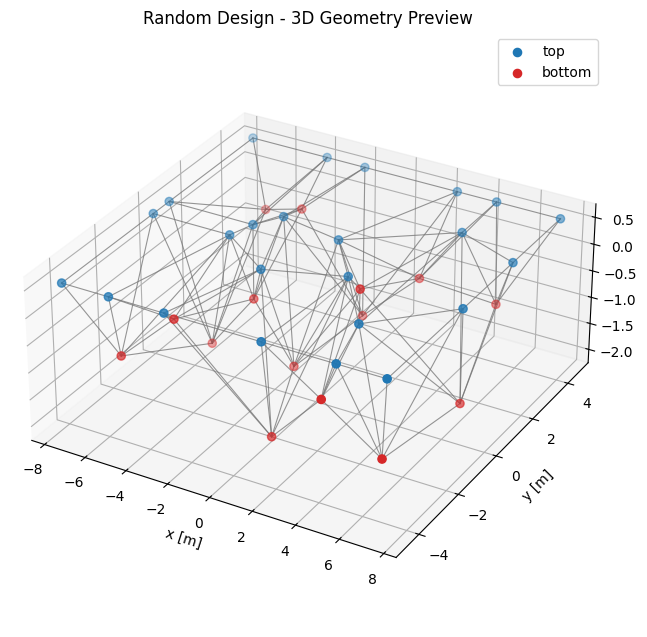

In [2]:
import importlib
import matplotlib.pyplot as plt
import c23_stage_geometry as stage_geometry

importlib.reload(stage_geometry)

geometry_out = stage_geometry.run_random_geometry_stage(
    json_path=json_path if "json_path" in globals() else None,
    optimizer_search_space=optimizer_search_space if "optimizer_search_space" in globals() else None,
    sample_id=0,
)

my_random_design = geometry_out["my_random_design"]
vertices_list = geometry_out["vertices_list"]
df_vertices = geometry_out["df_vertices"]
df_edges = geometry_out["df_edges"]
df_geometry_overview = geometry_out["df_geometry_overview"]

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(5))

fig, ax = stage_geometry.plot_geometry_preview(
    df_vertices=df_vertices,
    df_edges=df_edges,
    figsize=(8, 7),
)
plt.show()

# Feasibility check

In [ ]:
import importlib
import c25_feasibility_check as feasibility_check
from workflows import c25_stage_feasibility as stage_feasibility

importlib.reload(feasibility_check)
importlib.reload(stage_feasibility)

MODEL_PREFIX = "ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857"
SURROGATE_EDGE_FEATURE_MODE = "area_length"  # switch to "length_only" for the simple model

feasibility_out = stage_feasibility.run_feasibility_stage(
    df_input_stock=df_input_stock,
    df_vertices=df_vertices,
    df_edges=df_edges,
    model_prefix=MODEL_PREFIX,
    export_slots_path=None,
    force_mode="surrogate",
    surrogate_edge_feature_mode=SURROGATE_EDGE_FEATURE_MODE,
)

# Compatibility variables used by downstream cost/milp cells
SURROGATE_BUNDLE = feasibility_out["bundle"]
df_slots = feasibility_out["df_slots"]
df_safe_options = feasibility_out["df_safe_options"]
df_failure_reasons = feasibility_out["df_failure_reasons"]
feasibility_summary = feasibility_out["summary"]

print(
    f"C25 feasibility: {feasibility_summary['slots']} slots x {feasibility_summary['stock_items']} stock, "
    f"feasible pairs={feasibility_summary['feasible_pairs']}/{feasibility_summary['total_pairs']} "
)

# Export feasibility artifacts for downstream reporting/auditing
export_dir = config.EXPORT_PATH
export_dir.mkdir(parents=True, exist_ok=True)

target_edge_for_failure = "e24"
feasibility_matrix_path = export_dir / f"c25_feasibility_matrix_{SURROGATE_EDGE_FEATURE_MODE}.csv"
structure_slots_path = export_dir / f"c25_structure_slots_{SURROGATE_EDGE_FEATURE_MODE}.csv"
failure_reasons_path = export_dir / f"c25_failure_reasons_edge_{target_edge_for_failure}_{SURROGATE_EDGE_FEATURE_MODE}.csv"

df_feasibility_matrix.to_csv(feasibility_matrix_path, index=True)
df_slots.to_csv(structure_slots_path, index=False)

failure_reasons_edge = df_failure_reasons[
    df_failure_reasons["edge_id"].astype(str).str.strip().str.lower() == target_edge_for_failure.lower()
]
failure_reasons_edge.to_csv(failure_reasons_path, index=False)

print(f"Exported feasibility matrix: {feasibility_matrix_path}")
print(f"Exported structure slots: {structure_slots_path}")
print(f"Exported utilization matrix: {utilization_matrix_path}")
print(
    f"Exported failure reasons for {target_edge_for_failure}: {failure_reasons_path} "
    f"(rows={len(failure_reasons_edge)})"
)

Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Loaded surrogate prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6
Device: cpu
Model: ID20260418_215020_LR0.0005_EP100_R0.99_surrogate_model.pt
Model variant: v1
C25 feasibility: 32 slots x 480 stock, feasible pairs=8133/15360 (utilization <= 1.00)


,edge_id,length_m,axial_force_kn,Length_Req,Depth_Req,Width_Req,governing_utilization,Area_Req
0,e0,3.375000,40.371906,3375,150.0,38.0,0.904828,0.00570
1,e1,3.375000,52.799484,3375,100.0,75.0,0.900261,0.00750
2,e2,2.625000,-8.671871,2625,150.0,50.0,0.846670,0.00750
3,e3,1.912132,10.860046,1912,100.0,38.0,0.364893,0.00380
4,e4,2.250000,-25.051508,2250,225.0,50.0,0.988994,0.01125


,NS_00000,NS_00001,NS_00002,NS_00003,NS_00004,NS_00005,NS_00006,NS_00007,NS_00008,NS_00009,...,RS_00029,RS_00030,RS_00031,RS_00032,RS_00033,RS_00034,RS_00035,RS_00036,RS_00037,RS_00038
e0,1.356481,1.031209,0.818856,0.688160,0.516608,0.904828,0.688160,0.546562,0.459417,0.344980,...,0.875840,0.644658,0.409225,0.392272,0.875840,0.644658,0.409225,0.392272,0.875840,0.644658
e1,1.774043,1.349061,1.071324,0.900261,0.675660,1.183776,0.900261,0.714876,0.600780,0.450954,...,1.145786,0.843116,0.534891,0.512712,1.145786,0.843116,0.534891,0.512712,1.145786,0.843116
e2,2.280167,1.027860,0.530568,0.325480,0.151457,1.535270,0.694148,0.359411,0.221108,0.103462,...,0.846670,0.446337,0.218326,0.164750,0.846670,0.446337,0.218326,0.164750,0.846670,0.446337
e3,0.364893,0.279547,0.223783,0.189367,0.144095,0.246361,0.189367,0.152000,0.129065,0.099125,...,0.241012,0.180005,0.118367,0.113944,0.241012,0.180005,0.118367,0.113944,0.241012,0.180005
e4,4.890117,2.205841,1.142889,0.706906,0.343137,3.268672,1.475699,0.765310,0.473759,0.230341,...,1.798876,0.944636,0.456496,0.347863,1.798876,0.944636,0.456496,0.347863,1.798876,0.944636


Exported feasibility matrix: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_feasibility_matrix_area_length.csv
Exported structure slots: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_structure_slots_area_length.csv
Exported utilization matrix: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_utilization_matrix_area_length.csv
Exported failure reasons for e24: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_failure_reasons_edge_e24_area_length.csv (rows=151)


## Surrogate model testing

In [8]:
# -------------------------------
# DIAGNOSTIC: LENGTH-ONLY vs AREA-LENGTH
# -------------------------------
import numpy as np
import pandas as pd

# Re-run both modes on the same geometry + stock for an apples-to-apples comparison.
compare_modes = ["area_length", "length_only"]
mode_outputs = {}

for mode in compare_modes:
    print(f"\nRunning diagnostic feasibility for mode: {mode}")
    mode_outputs[mode] = stage_feasibility.run_feasibility_stage(
        df_input_stock=df_input_stock,
        df_vertices=df_vertices,
        df_edges=df_edges,
        model_prefix_complex=MODEL_PREFIX_COMPLEX,
        model_prefix_simple=MODEL_PREFIX_SIMPLE,
        gnn_margin=1.10,
        utilization_threshold=1.00,
        export_slots_path=None,
        force_mode="surrogate",
        surrogate_edge_feature_mode=mode,
    )


def _series_stats(values: np.ndarray) -> dict[str, float]:
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return {"count": 0, "min": np.nan, "q05": np.nan, "median": np.nan, "q95": np.nan, "max": np.nan, "mean": np.nan}
    return {
        "count": int(finite.size),
        "min": float(np.min(finite)),
        "q05": float(np.quantile(finite, 0.05)),
        "median": float(np.median(finite)),
        "q95": float(np.quantile(finite, 0.95)),
        "max": float(np.max(finite)),
        "mean": float(np.mean(finite)),
    }

# 1) Force comparison per edge
forces_area = mode_outputs["area_length"]["df_forces"][["edge_id", "axial_force_kn"]].rename(columns={"axial_force_kn": "axial_force_area"})
forces_len = mode_outputs["length_only"]["df_forces"][["edge_id", "axial_force_kn"]].rename(columns={"axial_force_kn": "axial_force_length"})

force_cmp = forces_area.merge(forces_len, on="edge_id", how="inner")
force_cmp["delta_kn"] = force_cmp["axial_force_length"] - force_cmp["axial_force_area"]
force_cmp["abs_delta_kn"] = force_cmp["delta_kn"].abs()
force_cmp["rel_delta_vs_area"] = force_cmp["delta_kn"] / force_cmp["axial_force_area"].replace(0.0, np.nan)

# 2) Utilization distribution comparison
util_stats_rows = []
for mode in compare_modes:
    util_vals = np.asarray(mode_outputs[mode]["df_utilization_matrix_values"], dtype=float).reshape(-1)
    row = {"mode": mode, **_series_stats(util_vals)}
    util_stats_rows.append(row)
util_stats = pd.DataFrame(util_stats_rows)

# 3) Force distribution comparison
force_stats_rows = []
for mode in compare_modes:
    force_vals = np.asarray(mode_outputs[mode]["df_forces"]["axial_force_kn"], dtype=float)
    row = {"mode": mode, **_series_stats(force_vals)}
    force_stats_rows.append(row)
force_stats = pd.DataFrame(force_stats_rows)

print("\nForce distribution by mode:")
display(force_stats)

print("\nUtilization distribution by mode:")
display(util_stats)

print("\nTop 10 edges by absolute force delta (length_only - area_length):")
display(force_cmp.sort_values("abs_delta_kn", ascending=False).head(10))

# Export diagnostic artifacts
diag_dir = config.EXPORT_PATH
diag_dir.mkdir(parents=True, exist_ok=True)

force_cmp_path = diag_dir / "c25_diagnostic_force_compare_length_vs_area.csv"
force_stats_path = diag_dir / "c25_diagnostic_force_stats_by_mode.csv"
util_stats_path = diag_dir / "c25_diagnostic_utilization_stats_by_mode.csv"

force_cmp.to_csv(force_cmp_path, index=False)
force_stats.to_csv(force_stats_path, index=False)
util_stats.to_csv(util_stats_path, index=False)

print(f"Exported force comparison: {force_cmp_path}")
print(f"Exported force stats: {force_stats_path}")
print(f"Exported utilization stats: {util_stats_path}")


Running diagnostic feasibility for mode: area_length
Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length
Loaded surrogate prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6
Device: cpu
Model: ID20260418_215020_LR0.0005_EP100_R0.99_surrogate_model.pt
Model variant: v1

Running diagnostic feasibility for mode: length_only
Using surrogate model prefix: ID20260421_193347_LR0.0005_EP150_R0.99_F5 with edge feature mode: length_only
Loaded surrogate prefix: ID20260421_193347_LR0.0005_EP150_R0.99_F5
Device: cpu
Model: ID20260421_193347_LR0.0005_EP150_R0.99_surrogate_model.pt
Model variant: v1

Force distribution by mode:


,mode,count,min,q05,median,q95,max,mean
0,area_length,32,-25.051508,-18.528779,25.510483,49.099007,52.799484,19.625333
1,length_only,32,-794.687805,-524.251328,315.777817,1307.535596,1352.012573,300.106669



Utilization distribution by mode:


,mode,count,min,q05,median,q95,max,mean
0,area_length,15360,0.000252,0.016260,0.276345,1.146375,7.606751,0.411444
1,length_only,15360,0.003989,0.168201,6.051848,41.601673,322.069425,12.078683



Top 10 edges by absolute force delta (length_only - area_length):


,edge_id,axial_force_area,axial_force_length,delta_kn,abs_delta_kn,rel_delta_vs_area
8,e8,47.994354,1352.012573,1304.018188,1304.018188,27.170240
30,e30,33.711082,1323.539307,1289.828247,1289.828247,38.261253
10,e10,48.227551,1294.441650,1246.214111,1246.214111,25.840294
27,e27,23.546598,1205.577759,1182.031128,1182.031128,50.199654
1,e1,52.799484,1047.158447,994.358948,994.358948,18.832739
24,e24,33.732971,940.688599,906.955627,906.955627,26.886326
6,e6,44.954010,-794.687805,-839.641846,839.641846,-18.677797
18,e18,37.942089,840.629028,802.686951,802.686951,21.155581
13,e13,-1.170608,790.327820,791.498413,791.498413,-676.143250
4,e4,-25.051508,586.085205,611.136719,611.136719,-24.395206


Exported force comparison: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_diagnostic_force_compare_length_vs_area.csv
Exported force stats: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_diagnostic_force_stats_by_mode.csv
Exported utilization stats: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_diagnostic_utilization_stats_by_mode.csv


In [9]:
# -------------------------------
# DIAGNOSTIC: PREDICTIONS vs RECONSTRUCTED TEST TARGETS
# -------------------------------
import numpy as np
import pandas as pd
import c21_surrogate_io as surrogate_io


def _dist(values: np.ndarray) -> dict[str, float]:
    v = values[np.isfinite(values)]
    if v.size == 0:
        return {"count": 0, "min": np.nan, "q05": np.nan, "median": np.nan, "q95": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan}
    return {
        "count": int(v.size),
        "min": float(np.min(v)),
        "q05": float(np.quantile(v, 0.05)),
        "median": float(np.median(v)),
        "q95": float(np.quantile(v, 0.95)),
        "max": float(np.max(v)),
        "mean": float(np.mean(v)),
        "std": float(np.std(v)),
    }


def _resolve_mode_prefix(mode: str) -> str:
    if mode == "area_length":
        return MODEL_PREFIX_COMPLEX
    return MODEL_PREFIX_SIMPLE


def _reconstruct_test_targets(prefix: str) -> tuple[np.ndarray, dict[str, object]]:
    bundle = surrogate_io.load_surrogate_bundle(prefix_sm=prefix)
    manifest = bundle.get("run_manifest") or {}

    data_sources = manifest.get("dataset_sources") or {}
    edge_name = data_sources.get("edge")
    if edge_name is None:
        raise ValueError(f"No edge dataset source recorded in manifest for prefix {prefix}")

    edge_csv = config.GH_DATA_PATH / edge_name
    if not edge_csv.exists():
        raise FileNotFoundError(f"Edge source file not found: {edge_csv}")

    df_edge = pd.read_csv(edge_csv)
    sample_col = "Sample_ID" if "Sample_ID" in df_edge.columns else "sample_id"
    if sample_col not in df_edge.columns:
        raise ValueError(f"Edge source {edge_csv.name} misses sample id column (Sample_ID/sample_id)")

    target_col = str(manifest.get("target_col", "Axial_Force"))
    if target_col not in df_edge.columns:
        raise ValueError(f"Edge source {edge_csv.name} misses target column {target_col}")

    random_seed = int(manifest.get("random_seed", 42))
    train_split_ratio = float(manifest.get("train_split_ratio", 0.8))

    sample_ids = sorted(df_edge[sample_col].dropna().astype(int).unique().tolist())
    rng = np.random.default_rng(random_seed)
    shuffled = np.array(rng.permutation(sample_ids), dtype=int)
    train_size = int(train_split_ratio * len(shuffled))
    test_ids = set(shuffled[train_size:].tolist())

    y_test = df_edge.loc[df_edge[sample_col].astype(int).isin(test_ids), target_col].to_numpy(dtype=float)

    meta = {
        "prefix": prefix,
        "edge_source": str(edge_csv),
        "target_col": target_col,
        "random_seed_used": random_seed,
        "train_split_ratio_used": train_split_ratio,
        "n_samples_total": int(len(sample_ids)),
        "n_samples_test": int(len(test_ids)),
        "n_edges_test": int(y_test.size),
        "manifest_has_random_seed": bool("random_seed" in manifest),
        "manifest_has_train_split_ratio": bool("train_split_ratio" in manifest),
    }
    return y_test, meta


rows = []
for mode in ["area_length", "length_only"]:
    prefix = _resolve_mode_prefix(mode)
    y_test, meta = _reconstruct_test_targets(prefix)

    # Use already computed force predictions from previous diagnostic cell when available.
    if "mode_outputs" in globals() and mode in mode_outputs:
        y_pred = mode_outputs[mode]["df_forces"]["axial_force_kn"].to_numpy(dtype=float)
    else:
        tmp = stage_feasibility.run_feasibility_stage(
            df_input_stock=df_input_stock,
            df_vertices=df_vertices,
            df_edges=df_edges,
            model_prefix_complex=MODEL_PREFIX_COMPLEX,
            model_prefix_simple=MODEL_PREFIX_SIMPLE,
            gnn_margin=1.10,
            utilization_threshold=1.00,
            export_slots_path=None,
            force_mode="surrogate",
            surrogate_edge_feature_mode=mode,
        )
        y_pred = tmp["df_forces"]["axial_force_kn"].to_numpy(dtype=float)

    test_stats = _dist(y_test)
    pred_stats = _dist(y_pred)

    test_min, test_max = test_stats["min"], test_stats["max"]
    pred_outside = int(np.sum((y_pred < test_min) | (y_pred > test_max))) if np.isfinite(test_min) and np.isfinite(test_max) else np.nan

    rows.append({
        "mode": mode,
        "prefix": prefix,
        "test_count": test_stats["count"],
        "test_min": test_stats["min"],
        "test_q05": test_stats["q05"],
        "test_median": test_stats["median"],
        "test_q95": test_stats["q95"],
        "test_max": test_stats["max"],
        "test_mean": test_stats["mean"],
        "test_std": test_stats["std"],
        "pred_count": pred_stats["count"],
        "pred_min": pred_stats["min"],
        "pred_q05": pred_stats["q05"],
        "pred_median": pred_stats["median"],
        "pred_q95": pred_stats["q95"],
        "pred_max": pred_stats["max"],
        "pred_mean": pred_stats["mean"],
        "pred_std": pred_stats["std"],
        "pred_outside_test_range_count": pred_outside,
        "random_seed_used": meta["random_seed_used"],
        "train_split_ratio_used": meta["train_split_ratio_used"],
        "manifest_has_random_seed": meta["manifest_has_random_seed"],
        "manifest_has_train_split_ratio": meta["manifest_has_train_split_ratio"],
    })

summary_compare = pd.DataFrame(rows)

print("Reconstructed test-target vs current-geometry prediction distribution:")
display(summary_compare)

if not bool(summary_compare["manifest_has_random_seed"].all()) or not bool(summary_compare["manifest_has_train_split_ratio"].all()):
    print("WARNING: run manifests do not store split seed/ratio explicitly; diagnostic used fallback seed=42 and split=0.8 from training convention.")

summary_compare_path = config.EXPORT_PATH / "c25_diagnostic_pred_vs_reconstructed_test_distribution.csv"
summary_compare.to_csv(summary_compare_path, index=False)
print(f"Exported reconstructed-test comparison: {summary_compare_path}")

Loaded surrogate prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6
Device: cpu
Model: ID20260418_215020_LR0.0005_EP100_R0.99_surrogate_model.pt
Model variant: v1
Loaded surrogate prefix: ID20260421_193347_LR0.0005_EP150_R0.99_F5
Device: cpu
Model: ID20260421_193347_LR0.0005_EP150_R0.99_surrogate_model.pt
Model variant: v1
Reconstructed test-target vs current-geometry prediction distribution:


,mode,prefix,test_count,test_min,test_q05,test_median,test_q95,test_max,test_mean,test_std,...,pred_median,pred_q95,pred_max,pred_mean,pred_std,pred_outside_test_range_count,random_seed_used,train_split_ratio_used,manifest_has_random_seed,manifest_has_train_split_ratio
0,area_length,ID20260418_215020_LR0.0005_EP100_R0.99_F6,128000,-200.2449,-27.76992,3.17945,45.619205,309.4488,5.632588,23.876845,...,25.510483,49.099007,52.799484,19.625333,22.645149,0,42,0.8,False,False
1,length_only,ID20260421_193347_LR0.0005_EP150_R0.99_F5,128000,-200.2449,-27.76992,3.17945,45.619205,309.4488,5.632588,23.876845,...,315.777817,1307.535596,1352.012573,300.106669,590.022223,23,42,0.8,False,False


Exported reconstructed-test comparison: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_diagnostic_pred_vs_reconstructed_test_distribution.csv


# COST, MATCHING AND FITNESS

In [5]:
import importlib
import json
import pandas as pd
import config
from workflows import c26_stage_cost_matrix as stage_cost
from workflows import c27_stage_milp as stage_milp
from workflows import c28_stage_fitness as stage_fitness

importlib.reload(stage_cost)
importlib.reload(stage_milp)
importlib.reload(stage_fitness)

# -------------------------------
# STEP 1: COST MATRIX STAGE
# -------------------------------
target_slot_for_analysis = "e20"

cost_out = stage_cost.run_cost_matrix_stage(
    df_slots=df_slots,
    df_input_stock=df_input_stock,
    df_utilization_matrix=df_utilization_matrix_values if "df_utilization_matrix_values" in globals() else df_utilization_matrix,
    utilization_threshold=1.00,
    cost_formula_version="v2",
    include_threshold_sweep=False,
    export_slot_analysis=True,
    target_slot_for_analysis=target_slot_for_analysis,
    export_dir=config.EXPORT_PATH,
    quiet=True,
)

cost_matrix = cost_out["cost_matrix"]
enriched_stock = cost_out["enriched_stock"]
df_logs = cost_out["df_logs"]
df_cost_matrix_display = cost_out["df_cost_matrix_display"]
df_threshold_sweep = cost_out["df_threshold_sweep"]
slot_analysis = cost_out["slot_analysis"]
cost_summary = cost_out["summary"]

# Notebook-owned exports
export_dir = config.EXPORT_PATH
export_dir.mkdir(parents=True, exist_ok=True)
final_cost_matrix_path = export_dir / "c26_final_cost_matrix.csv"
df_cost_matrix_display.to_csv(final_cost_matrix_path, index=True)
print(f"Exported final cost matrix: {final_cost_matrix_path}")

if slot_analysis is not None:
    slot_analysis_path = slot_analysis["analysis_export_path"]
    slot_analysis["df_logs_slot"].to_csv(slot_analysis_path, index=False)
    print(f"Exported slot analysis: {slot_analysis_path}")
    if slot_analysis.get("df_logs_slot_rs") is not None and len(slot_analysis["df_logs_slot_rs"]) > 0:
        rs_analysis_path = slot_analysis_path.with_name(f"{slot_analysis_path.stem}_rs.csv")
        slot_analysis["df_logs_slot_rs"].to_csv(rs_analysis_path, index=False)
        print(f"Exported RS slot analysis: {rs_analysis_path}")

if df_threshold_sweep is not None and len(df_threshold_sweep) > 0:
    threshold_sweep_path = export_dir / "c26_threshold_sweep.csv"
    df_threshold_sweep.to_csv(threshold_sweep_path, index=False)
    print(f"Exported threshold sweep: {threshold_sweep_path}")

print(
    f"Cost matrix: {cost_summary['slots']} slots x {cost_summary['stock_items']} stock, "
    f"valid={cost_summary['valid_pairs']}/{cost_summary['total_pairs']} "
    f"(pruned={cost_summary.get('pruned_pairs', 0)}), "
    f"utilization_mode={cost_summary.get('utilization_mode', 'unknown')}, "
    f"cost_formula_version={cost_summary.get('cost_formula_version', 'unknown')}"
)

if df_threshold_sweep is not None and len(df_threshold_sweep) > 0:
    print("Threshold sweep summary:")
    display(df_threshold_sweep)

if slot_analysis is not None:
    print(f"Detailed slot analysis prepared: {slot_analysis['analysis_export_path']}")

# -------------------------------
# STEP 2: MILP STAGE
# -------------------------------
print("Starting MILP optimizer...")
milp_out = stage_milp.run_milp_stage(
    cost_matrix=cost_matrix,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,
    solver_msg=False,
    raise_on_infeasible_slots=True,
)

status = milp_out["status"]
df_results = milp_out["df_results"]
total_cost = milp_out["total_cost"]
milp_summary = milp_out["summary"]

df_results.to_csv(config.EXPORT_PATH / "c27_milp_results.csv", index=False)

print(
    f"MILP setup: {milp_summary['reclaimed_items']} reclaimed + "
    f"{milp_summary['new_items']} new stock items for {milp_summary['slots']} slots"
)
print(f"MILP status: {status}")
print(f"Total assignment cost: {total_cost:.2f}")
if len(df_results) > 0:
    display(df_results.head(10))

Exported final cost matrix: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c26_final_cost_matrix.csv
Exported slot analysis: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c26_depth_analysis_e20.csv
Exported RS slot analysis: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c26_depth_analysis_e20_rs.csv
Cost matrix: 32 slots x 480 stock, valid=14243/15360 (pruned=1117), utilization_mode=c25_feasibility_matrix, cost_formula_version=v2
Detailed slot analysis prepared: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c26_depth_analysis_e20.csv
Starting MILP optimizer...
MILP setup: 38 reclaimed + 442 new stock items for 32 slots
MILP status: Optimal
Total assignment cost: 18.65


,edge_id,assigned_timber,CO2_Penalty
0,e0,RS_00006,0.578400
1,e1,RS_00026,0.435078
2,e2,RS_00018,0.521083
3,e3,NS_00204,0.785344
4,e4,RS_00002,0.389862
5,e5,RS_00017,0.415922
6,e6,RS_00003,0.805098
7,e7,NS_00204,0.936859
8,e8,RS_00022,0.467297
9,e9,RS_00027,0.674358


In [6]:
# -------------------------------
# STEP 2.5: FITNESS NORMALIZATION BOUNDS
# -------------------------------
from workflows import c28_stage_normalization_bounds as stage_bounds

bounds_out = stage_bounds.run_normalization_bounds_stage(
    cost_matrix=cost_matrix,
    df_logs=df_logs,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,   # match your c27 call
    solver_msg=False,
    print_summary=True,
)

normalization_constants = bounds_out["normalization_constants"]
print(normalization_constants)
# -> {"C_max": ..., "R_max": ..., "W_max": ...}

Bounds status: Optimal
Normalization constants C_max=85.91042982759222, R_max=100.0, W_max=5.989648585796354
{'C_max': 85.91042982759222, 'R_max': 100.0, 'W_max': 5.989648585796354}


In [7]:
# -------------------------------
# STEP 3: FITNESS STAGE
# -------------------------------
fitness_weights = {
    "omega_1": 1.0,
    "omega_2": 1.0,
    "omega_3": 1.0,
}

fitness_out = stage_fitness.run_fitness_stage(
    df_results=df_results,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    total_cost=total_cost,
    weight_config=fitness_weights,
    normalization_constants=normalization_constants,
    derive_normalization_constants=False,
    run_sanity_checks=True,
    print_breakdown=True,
)

fitness_result = fitness_out["fitness_result"]
normalization_constants = fitness_out["normalization_constants"]

print("Fitness summary:")
print(f"  objective: {fitness_result.get('objective', 'n/a')}")
print(f"  feasible: {fitness_result.get('is_feasible', 'n/a')}")
print(f"  fitness: {fitness_result.get('fitness', 'n/a')}\n")

# Notebook-owned fitness exports
fitness_json_path = config.EXPORT_PATH / "c28_fitness_result.json"
fitness_csv_path = config.EXPORT_PATH / "c28_fitness_result.csv"

fitness_json_path.parent.mkdir(parents=True, exist_ok=True)

# Convert numpy scalars to native Python values for stable JSON serialization.
def _to_builtin(value):
    return value.item() if hasattr(value, "item") else value

fitness_export = {key: _to_builtin(value) for key, value in fitness_result.items()}
fitness_export["weights"] = {
    "omega_1": float(fitness_weights["omega_1"]),
    "omega_2": float(fitness_weights["omega_2"]),
    "omega_3": float(fitness_weights["omega_3"]),
}
fitness_export["normalization_constants"] = {
    "C_max": float(normalization_constants["C_max"]),
    "R_max": float(normalization_constants["R_max"]),
    "W_max": float(normalization_constants["W_max"]),
}

with open(fitness_json_path, "w", encoding="utf-8") as f:
    json.dump(fitness_export, f, indent=2)

fitness_row = {
    **{key: _to_builtin(value) for key, value in fitness_result.items()},
    **fitness_weights,
    "C_max": float(normalization_constants["C_max"]),
    "R_max": float(normalization_constants["R_max"]),
    "W_max": float(normalization_constants["W_max"]),
}
pd.DataFrame([fitness_row]).to_csv(fitness_csv_path, index=False)

print(f"Exported fitness JSON: {fitness_json_path}")
print(f"Exported fitness CSV: {fitness_csv_path}")


MULTI-OBJECTIVE FITNESS EVALUATION

Raw Metrics:
  MILP Cost:          18.652 kg CO2e
  Reuse Rate:           84.4 %
  Total Waste:        0.4392 m3

Normalized (0-1 range):
  Cost (norm):         0.217
  Reuse (norm):        0.844
  Waste (norm):        0.073

Weights Applied:
  omega_1 (cost):      1.000
  omega_2 (reuse):     1.000
  omega_3 (waste):     1.000

Weighted Components:
  omega_1 x cost:      0.217
  omega_2 x reuse:     0.844 (subtracted)
  omega_3 x waste:     0.073

Final Fitness:
  F(x) = 0.217 - 0.844 + 0.073
  F(x) =   -0.553

Interpretation:
  [EXCELLENT] Strong reclaimed reuse and low waste relative to cost
  Bands: <= -0.25 excellent, <= 0.25 good, <= 0.75 fair, > 0.75 poor

Fitness summary:
  objective: 18.65153187133206
  feasible: True
  fitness: -0.5533122128529284

Exported fitness JSON: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c28_fitness_result.json
Exported fitness CSV: C:\Users\jaspe\OneDrive\06 Building Technolog

# EXPORT

Exports structural parameters (vertices + edges with assigned timber) for Grasshopper reconstruction.

In [ ]:
# Export geometry + matching results
import pandas as pd
import config

EXPORT_PREFIX = "c29_optimum"
required_vars = ["df_vertices", "df_edges", "df_results"]
if any(name not in globals() for name in required_vars):
    raise ValueError(f"Missing: {', '.join(required_vars)}")

df_edges_export = pd.merge(df_edges, df_results[["edge_id", "assigned_timber", "CO2_Penalty"]], on="edge_id", how="left")
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges.csv", index=False)
n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")

# LITERATURE

### COST MATRIX
We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

### MATCHING ALGORITHM / MILP
The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

### MULTI-OBJECTIVE FITNESS FUNCTION

The fitness function balances three competing objectives:

$$F(\mathbf{x}) = \omega_1 \left( \frac{f_{inner}^*(\mathbf{x})}{\mathcal{C}_{max}} \right) - \omega_2 \left( \frac{\mathcal{R}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{R}_{max}} \right) + \omega_3 \left( \frac{\mathcal{W}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{W}_{max}} \right)$$

- **$f_{inner}^*$**: MILP cost (kg CO2e) — penalizes virgin material and waste
- **$\mathcal{R}$**: Reuse rate (%) — reward for using reclaimed timber (subtracted, so higher reuse = better)
- **$\mathcal{W}$**: Total waste (m³) — penalizes inefficient cutting
- **$\omega_i$**: Weight coefficients to tune priorities

All metrics are normalized to [0, 1] using precomputed dataset-driven extremes ($\mathcal{C}_{max}$, $\mathcal{R}_{max}$, $\mathcal{W}_{max}$).

**Design philosophy**: The MILP cost matrix already accounts for all physical and geometric infeasibilities (by returning ∞ for impossible assignments). This means the upper-level fitness function does NOT need a conditional fallback loop. Instead, we can directly minimize a weighted multi-objective sum.

**Sign convention**:
- Positive coefficient on cost: higher MILP cost → higher (worse) fitness
- Negative coefficient on reuse: higher reuse rate → lower (better) fitness ✓
- Positive coefficient on waste: higher waste → higher (worse) fitness

**Typical design trade-offs**:
- High ω₁ (cost weight): prioritize LCA minimization across all materials
- High ω₂ (reuse weight): prioritize reclaimed material recovery
- High ω₃ (waste weight): prioritize cutting efficiency